In [1]:
import requests
import pandas as pd

url = "https://jsonplaceholder.typicode.com/users" 
response = requests.get(url)
data = response.json()

df_api = pd.DataFrame(data)
print(df_api[['id', 'name', 'company']].head())

   id              name                                            company
0   1     Leanne Graham  {'name': 'Romaguera-Crona', 'catchPhrase': 'Mu...
1   2      Ervin Howell  {'name': 'Deckow-Crist', 'catchPhrase': 'Proac...
2   3  Clementine Bauch  {'name': 'Romaguera-Jacobson', 'catchPhrase': ...
3   4  Patricia Lebsack  {'name': 'Robel-Corkery', 'catchPhrase': 'Mult...
4   5  Chelsey Dietrich  {'name': 'Keebler LLC', 'catchPhrase': 'User-c...


In [2]:
df = pd.read_csv("/Users/vildanpirpiroglu/Ironhack/03_Datasets/marketing_campaign_performance_10000.csv")
print(df.shape)

(10000, 11)


In [3]:
import os
for f in os.listdir(os.path.expanduser("~/Desktop")):
    if "marketing" in f.lower():
        print(repr(f))

In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install requests


In [6]:
print(df.head())


  CampaignID   StartDate     EndDate     Channel  Impressions  Clicks  Leads  \
0  CAMP00001  2025-04-13  2025-04-19      Search       293520   23335  11643   
1  CAMP00002  2025-12-15  2025-12-24      Search       200340   15841   6601   
2  CAMP00003  2025-09-28  2025-10-06       Email       239365   16478   8043   
3  CAMP00004  2025-04-17  2025-04-30      Search       156382    2672   1014   
4  CAMP00005  2025-03-13  2025-03-22  Influencer       285472    4155   1521   

   Conversions  Cost_USD  Revenue_USD   ROI  
0         5389   1052.39      2236.02  1.12  
1         2498   3964.90     11740.15  1.96  
2         3397   1000.39      1902.24  0.90  
3          342   1252.63      2209.74  0.76  
4          565   4935.48     14111.31  1.86  


In [7]:
# This tells  the exact shape of your data (Rows, Columns)
print(df.shape)


(10000, 11)


In [8]:
# This counts how many rows are exact carbon copies of another row
print(df.duplicated().sum())


0


In [9]:
# This looks at every column and counts the empty boxes
print(df.isnull().sum())


CampaignID     0
StartDate      0
EndDate        0
Channel        0
Impressions    0
Clicks         0
Leads          0
Conversions    0
Cost_USD       0
Revenue_USD    0
ROI            0
dtype: int64


In [10]:
# This lists out every single unique channel name exactly how Python sees it
print(df['Channel'].unique())


<StringArray>
['Search', 'Email', 'Influencer', 'Social', 'Display']
Length: 5, dtype: str


In [11]:
# This shows the technical "data type" of each column
print(df[['StartDate', 'EndDate']].dtypes)


StartDate    str
EndDate      str
dtype: object


In [12]:
# Convert StartDate and EndDate columns into real calendar dates
df['StartDate'] = pd.to_datetime(df['StartDate'])
df['EndDate'] = pd.to_datetime(df['EndDate'])

# Let's check them again to make sure it worked!
print(df[['StartDate', 'EndDate']].dtypes)


StartDate    datetime64[us]
EndDate      datetime64[us]
dtype: object


In [13]:
# Count how many rows have numbers below zero
negative_costs = (df['Cost_USD'] < 0).sum()
negative_revenues = (df['Revenue_USD'] < 0).sum()

print(f"Negative costs found: {negative_costs}")
print(f"Negative revenues found: {negative_revenues}")


Negative costs found: 0
Negative revenues found: 0


In [14]:
# Calculate the total days each campaign ran by subtracting the dates
df['Duration_Days'] = (df['EndDate'] - df['StartDate']).dt.days

# Let's inspect the first 5 rows to see your brand new column!
print(df[['StartDate', 'EndDate', 'Duration_Days']].head())


   StartDate    EndDate  Duration_Days
0 2025-04-13 2025-04-19              6
1 2025-12-15 2025-12-24              9
2 2025-09-28 2025-10-06              8
3 2025-04-17 2025-04-30             13
4 2025-03-13 2025-03-22              9


In [15]:
# Step 1: Group by Channel and find the average (mean) ROI
roi_summary = df.groupby('Channel')['ROI'].mean()

print(roi_summary)


Channel
Display       0.999304
Email         1.009990
Influencer    0.997529
Search        1.013389
Social        0.988020
Name: ROI, dtype: float64


In [16]:
# Create a new column to label campaigns as Short or Long
df['Length_Category'] = df['Duration_Days'].apply(lambda x: 'Short (1-7 Days)' if x <= 7 else 'Long (8+ Days)')

# Let's print out the first 5 rows to make sure our new labels are there!
print(df[['Duration_Days', 'Length_Category']].head())


   Duration_Days   Length_Category
0              6  Short (1-7 Days)
1              9    Long (8+ Days)
2              8    Long (8+ Days)
3             13    Long (8+ Days)
4              9    Long (8+ Days)


In [17]:
# Group by our new categories and calculate the average revenue
revenue_comparison = df.groupby('Length_Category')['Revenue_USD'].mean().reset_index()

print("--- AVERAGE REVENUE BY CAMPAIGN LENGTH ---")
print(revenue_comparison)


--- AVERAGE REVENUE BY CAMPAIGN LENGTH ---
    Length_Category  Revenue_USD
0    Long (8+ Days)  5131.431769
1  Short (1-7 Days)  5027.334702


In [18]:
channel_performance = (
    df.groupby('Channel')[['Conversions', 'ROI', 'Revenue_USD']]
    .mean()
    .sort_values('ROI', ascending=False)
    .round(2)
)
print("=== CHANNEL PERFORMANCE (sorted by ROI) ===")
print(channel_performance)

=== CHANNEL PERFORMANCE (sorted by ROI) ===
            Conversions   ROI  Revenue_USD
Channel                                   
Search          1014.42  1.01      5144.32
Email           1040.29  1.01      5075.42
Display          994.49  1.00      5178.89
Influencer      1021.98  1.00      5135.27
Social           982.11  0.99      4974.44


In [19]:
df['CTR'] = (df['Clicks'] / df['Impressions'] * 100).round(2)        # tıklama oranı
df['Conv_Rate'] = (df['Conversions'] / df['Clicks'] * 100).round(2)  # dönüşüm oranı
df['Cost_per_Conv'] = (df['Cost_USD'] / df['Conversions']).round(2)  # dönüşüm başı maliyet

channel_efficiency = df.groupby('Channel')[['CTR', 'Conv_Rate', 'Cost_per_Conv']].mean().round(2)
print(channel_efficiency)

             CTR  Conv_Rate  Cost_per_Conv
Channel                                   
Display     5.43      12.11          10.80
Email       5.46      12.12          10.13
Influencer  5.47      11.99           9.11
Search      5.52      12.12          10.89
Social      5.44      12.14          10.33


In [20]:
df.groupby('Channel').agg(
    kampanya_sayisi=('CampaignID', 'count'),
    ort_ROI=('ROI', 'mean'),
    toplam_gelir=('Revenue_USD', 'sum')
).round(2).sort_values('ort_ROI', ascending=False)

,kampanya_sayisi,ort_ROI,toplam_gelir
Channel,,,
Email,1996,1.01,10130542.61
Search,1924,1.01,9897677.79
Display,2069,1.00,10715125.21
Influencer,2056,1.00,10558118.99
Social,1955,0.99,9725024.70


In [21]:
best = channel_performance['ROI'].idxmax()
worst = channel_performance['ROI'].idxmin()
print(f"En yüksek ROI: {best} ({channel_performance.loc[best, 'ROI']})")
print(f"En düşük ROI:  {worst} ({channel_performance.loc[worst, 'ROI']})")

En yüksek ROI: Search (1.01)
En düşük ROI:  Social (0.99)


In [22]:
length_performance = (
    df.groupby('Length_Category')[['Revenue_USD', 'Conversions', 'ROI']]
    .mean()
    .round(2)
)
print("=== PERFORMANCE BY CAMPAIGN LENGTH ===")
print(length_performance)

=== PERFORMANCE BY CAMPAIGN LENGTH ===
                  Revenue_USD  Conversions   ROI
Length_Category                                 
Long (8+ Days)        5131.43       999.06  1.01
Short (1-7 Days)      5027.33      1041.17  0.99


In [23]:
df_api['company_name'] = df_api['company'].apply(lambda x: x['name'])
api_summary = df_api[['id', 'name', 'company_name']]
print("=== API SOURCE (JSONPlaceholder - live) ===")
print(api_summary)

=== API SOURCE (JSONPlaceholder - live) ===
   id                      name        company_name
0   1             Leanne Graham     Romaguera-Crona
1   2              Ervin Howell        Deckow-Crist
2   3          Clementine Bauch  Romaguera-Jacobson
3   4          Patricia Lebsack       Robel-Corkery
4   5          Chelsey Dietrich         Keebler LLC
5   6      Mrs. Dennis Schulist   Considine-Lockman
6   7           Kurtis Weissnat         Johns Group
7   8  Nicholas Runolfsdottir V     Abernathy Group
8   9           Glenna Reichert       Yost and Sons
9  10        Clementina DuBuque          Hoeger LLC


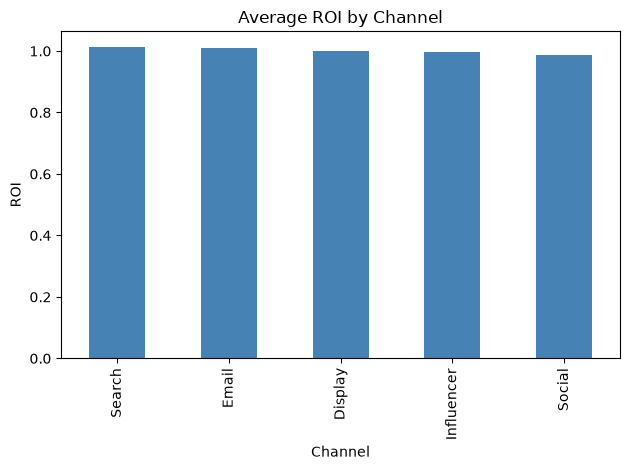

In [24]:
import matplotlib.pyplot as plt

channel_roi = df.groupby('Channel')['ROI'].mean().sort_values(ascending=False)
channel_roi.plot(kind='bar', color='steelblue', title='Average ROI by Channel')
plt.ylabel('ROI')
plt.tight_layout()
plt.show()

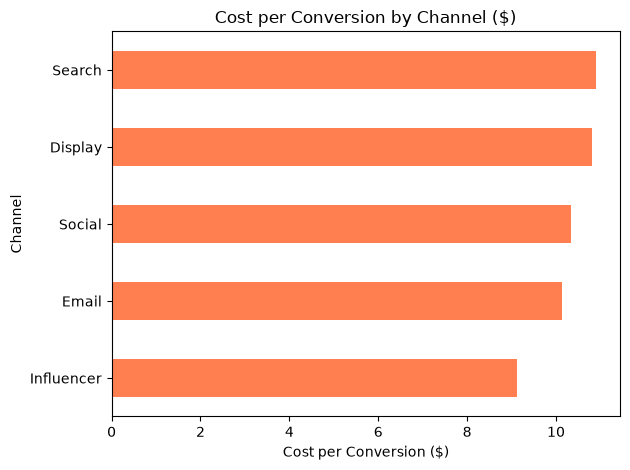

In [25]:
df.groupby('Channel')['Cost_per_Conv'].mean().sort_values().plot(
    kind='barh', color='coral', title='Cost per Conversion by Channel ($)'
)
plt.xlabel('Cost per Conversion ($)')
plt.tight_layout()
plt.show()

In [26]:
channel_performance.to_csv("channel_performance_analysis.csv")
print("✅ Saved: channel_performance_analysis.csv")

✅ Saved: channel_performance_analysis.csv


In [27]:
# HYPOTHESIS 2: Does higher budget lead to worse cost-per-lead?
df['Cost_per_Lead'] = (df['Cost_USD'] / df['Leads']).round(2)
df['Budget_Level'] = pd.qcut(df['Cost_USD'], q=3, labels=['Low', 'Medium', 'High'])

cpl_by_budget = df.groupby('Budget_Level')['Cost_per_Lead'].mean().round(2)
print("=== COST PER LEAD BY BUDGET LEVEL ===")
print(cpl_by_budget)

=== COST PER LEAD BY BUDGET LEVEL ===
Budget_Level
Low       1.32
Medium    3.50
High      6.25
Name: Cost_per_Lead, dtype: float64


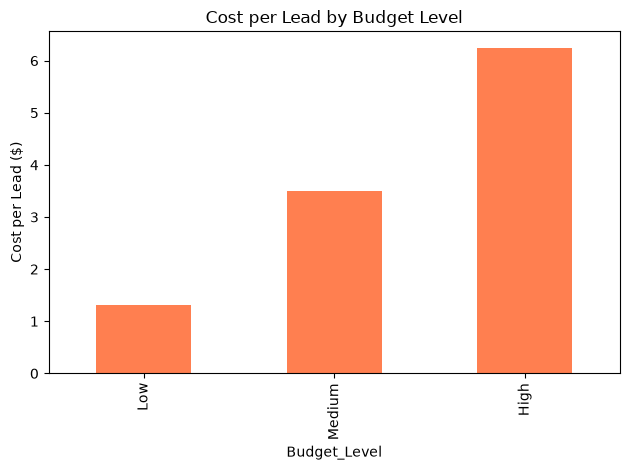

In [28]:
# Visualize Cost per Lead across budget levels
cpl_by_budget.plot(kind='bar', color='coral', title='Cost per Lead by Budget Level')
plt.ylabel('Cost per Lead ($)')
plt.tight_layout()
plt.show()

In [29]:
# HYPOTHESIS 3: Do channels with the highest spend also give the best return?
channel_spend_vs_return = df.groupby('Channel').agg(
    total_spend=('Cost_USD', 'sum'),
    avg_ROI=('ROI', 'mean'),
    avg_cost_per_conv=('Cost_per_Conv', 'mean')
).round(2).sort_values('total_spend', ascending=False)
print(channel_spend_vs_return)

            total_spend  avg_ROI  avg_cost_per_conv
Channel                                            
Display      5343184.30     1.00              10.80
Influencer   5278787.92     1.00               9.11
Email        5065029.98     1.01              10.13
Social       4919999.25     0.99              10.33
Search       4916568.46     1.01              10.89


In [30]:
# HYPOTHESIS 3: Do higher-impression campaigns convert more efficiently?
df['Impression_Level'] = pd.qcut(df['Impressions'], q=3, labels=['Low', 'Medium', 'High'])
impr_efficiency = df.groupby('Impression_Level')[['Conversions', 'ROI', 'Cost_per_Lead']].mean().round(2)
print(impr_efficiency)

                  Conversions   ROI  Cost_per_Lead
Impression_Level                                  
Low                    358.17  1.00           8.23
Medium                 992.81  1.00           1.82
High                  1681.31  1.01           1.03


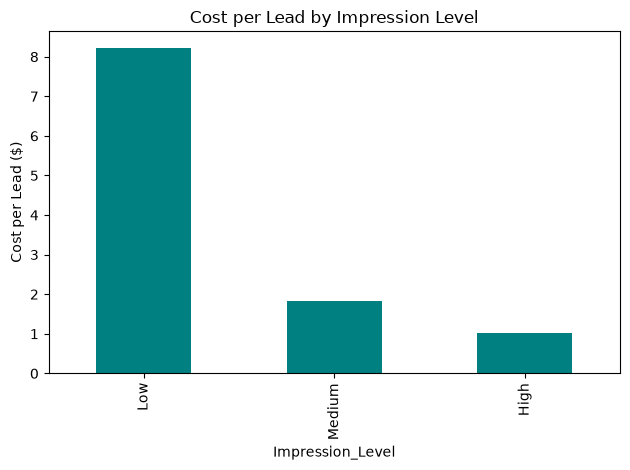

In [31]:
df.groupby('Impression_Level')['Cost_per_Lead'].mean().plot(
    kind='bar', color='teal', title='Cost per Lead by Impression Level')
plt.ylabel('Cost per Lead ($)')
plt.tight_layout()
plt.show()

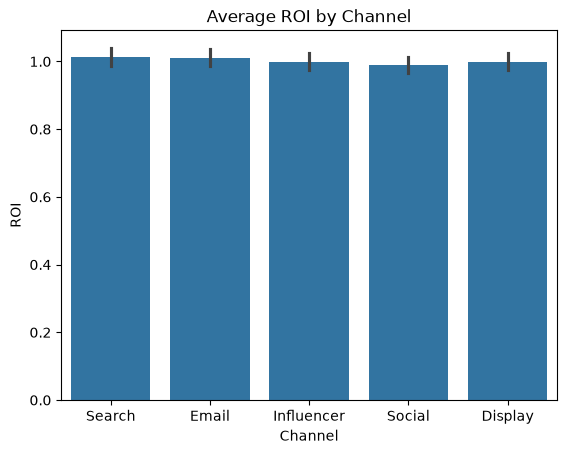

In [32]:
import seaborn as sns
sns.barplot(data=df, x='Channel', y='ROI')
plt.title('Average ROI by Channel')
plt.show()

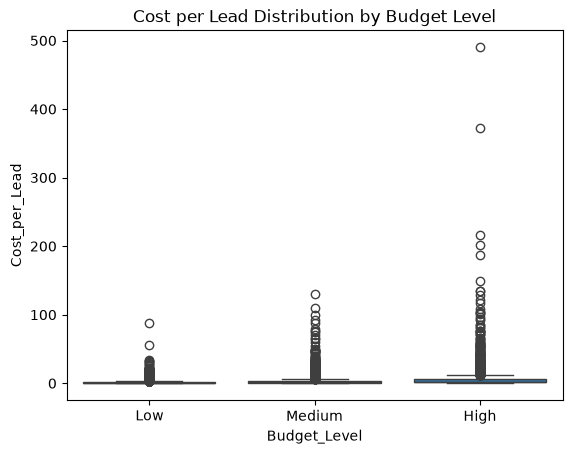

In [33]:
sns.boxplot(data=df, x='Budget_Level', y='Cost_per_Lead')
plt.title('Cost per Lead Distribution by Budget Level')
plt.show()

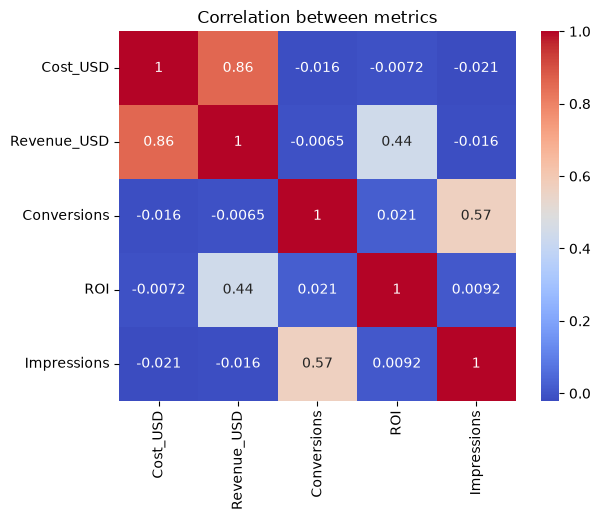

In [34]:
sns.heatmap(df[['Cost_USD','Revenue_USD','Conversions','ROI','Impressions']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between metrics')
plt.show()